# Wstęp do Sztucznej Inteligencji

Przed rozpoczęciem pracy z notatnikiem zmień jego nazwę zgodnie z wzorem: `NrAlbumu_Nazwisko_Imie_PoprzedniaNazwa`.

Przed wysłaniem notatnika upewnij się, że rozwiązałeś wszystkie zadania/ćwiczenia.

# Temat: Sztuczne Sieci Neuronowe - Lab 3 - Zadania (obowiązkowe)

# Biblioteka Keras. Aspekty uczenia sieci neuronowych.

## Sieci neuronowe w języku Python
Obecnie za sprawą rozwoju i popularności tzw. głębokich sieci neuronowych (Deep Neural Network) dostępnych jest bardzo dużo bibliotek/frameworków do budowy i uczenia sieci neuronowych (TensorFlow, Theano, Spark MLlib, MXNet, Microsoft Cognitive Toolkit, Caffe itp.). Z wielu z nich można korzystać w prosty sposób przy wykorzystaniu języka  Python.  

## Biblioteka Keras (na TensorFlow)
Biblioteka Keras jest wysokopoziomową nakładką na biblioteki takie jak TensorFlow, CNTK (Microsoft Cognitive Toolkit) lub Theano napisaną w języku Python. Domyślnie wykorzystywanym backendem jest TensorFlow i z takiego będziemy korzystać. Biblioteka ta pozwala na:
- Łatwe i szybkie prototypowanie modeli (pełna modularność).
- Wspiera zarówno "klasyczne" sieci neuronowe jak i konwolucyjne czy rekurencyjne. 
- Umożliwia uczenie przy wykorzystaniu CPU oraz GPU.

Keras: https://keras.io/

TensorFlow: https://www.tensorflow.org/

## Szybkie wprowadzenie na przykładzie sieci dla problemu XOR

### Dane:

In [1]:
import numpy as np

data_x = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])  # backpropagation nie lubi zer, bez biasu
data_y = np.array([0, 1, 1, 0])

### Import biblioteki Tensorflow i Keras
Biblioteke Kreas można zaimportować bezpośrednio `import keras` Jednak obecnie bublioteka Keras jest również dostępna jako podmoduł biblioteki Tensorflow.

In [2]:
import tensorflow as tf

print('Tensorflow version:', tf.__version__)
print('Keras z tensorflow version:', tf.keras.__version__)

I0000 00:00:1780060801.841554   17201 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780060801.874777   17201 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780060802.870611   17201 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Tensorflow version: 2.21.0
Keras z tensorflow version: 3.14.1


### Przygotowanie architektury sieci
Stworzenie sieci MLP o dwóch neuronach ukrytych i jednym wyjściowym:

Tworzenie modelu odbywa się na zasadzie budowania modelu z klocków (warstw). Najpierw tworzymy tensor będący warstwą wejściową `Input` a następnie dodajemy do niego kojejne warstwy np. `Dense` (warstwa neuronów typu każdy z każdym). Następnie dysponując tensorem wejściowym i wyjściowym określamy Model. Model można tworzyć też z wykorzystaniem klasy `Sequential`.

In [3]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense

In [4]:
x = Input(shape=(2,))  #należy ustawić kształ tensora wejściowego
h = Dense(2, use_bias=True, activation='tanh', kernel_initializer='random_uniform', bias_initializer='random_uniform')(
	x)  #parametry patrz dokumentacja
y = Dense(1, use_bias=True, activation='sigmoid', kernel_initializer='random_uniform',
          bias_initializer='random_uniform')(h)  # parametry patrz dokumentacja
# alternatywnie activation można ustawić na None i dodać funkcje aktywacj jako osobną warstwę
mlp = Model(inputs=x, outputs=y)

E0000 00:00:1780060807.540890   17201 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1780060807.541120   20197 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780060807.563188   17201 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
mlp.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
m2 = Sequential()
m2.add(
	Dense(2, use_bias=True, activation='tanh', kernel_initializer='random_uniform', bias_initializer='random_uniform',
	      input_shape=(2,)))
m2.add(Dense(1, use_bias=True, activation='sigmoid', kernel_initializer='random_uniform',
             bias_initializer='random_uniform'))

/home/user/intro-to-ai/11/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
m2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

### Kompilacja modelu
Po stworzeniu modelu należy go skompilować, podczas kompilacji podajemy m.in. rodzaj funkcji używanej do liczenia błędu (`loss`) oraz algorytm wykorzystywany do uczenia (`optimizer`). 

In [8]:
rms = tf.keras.optimizers.RMSprop(learning_rate=0.01)  #lr = learning rate; parametry patrz dokumentacja
mlp.compile(loss='mse', optimizer=rms)  #mse = mean squared error

In [9]:
m2.compile(loss='mse', optimizer=rms)

### Uczenie
Po kompilacji możemy przystąpić do uczenia za pomocą metody `fit`.

In [10]:
print('rozpoczecie uczenia')
#ustaw verbose=0 aby wyłączyć szczegóły 
hist = mlp.fit(data_x, data_y, epochs=300, verbose=1, batch_size=4)  #  parametry patrz dokumentacja
print('koniec uczenia')
# ponowne wykonanie powoduje douczanie a nie uczenie od nowa

rozpoczecie uczenia
Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 0.2500
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2500
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2500
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2500
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2500
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2500
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2500
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2500
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2500
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2500
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2500
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2500
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2500
Epoch 14/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2500
Epoch 15/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.250

Sprawdzenie czego model się nauczył:

In [11]:
pred = mlp.predict(data_x)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[0.14108962]
 [0.83132976]
 [0.8513765 ]
 [0.14147766]]


## Zagadnienie niedouczenia lub przeuczenia sieci
Przykładowy problem aproksymacji funkcji.

### Zwróć uwagę
- W rzeczywistości dane często pochodzą z pomiarów, które obarczone są niepewnością. W poniższym przykładzie modelujemy to poprzez dodanie losowego błędu do wartości funkcji sinus. 

- Funkcja sinus pełni tu rolę rzeczywistego modelu, którego w praktycznych problemach tak naprawdę nie znamy. Próbujemy go odkryć/aproksymować na podstawie dostępnych nam danych. 

- Celem nauki jest osiągnięcie dobrej generalizacji. Tutaj oznacza to, że sieć, na podstawie dostępnych (zaszumionych) przykładów, powinna nauczyć się prawidłowego przebiegu funkcji sinus. 

- Jeśli będziemy uczyć sieć zbyt długo, może pojawić się niekorzystny efekt zwany przeuczeniem. Ma to miejsce gdy sieć po odkryciu głównych zależności/ogólnego przebiegu funkcji, zaczyna dostosowywać się do szumu istniejącego w danych. Można temu przeciwdziałać poprzez odpowiednio wczesne zatrzymanie procesu uczenia. 

### Dane

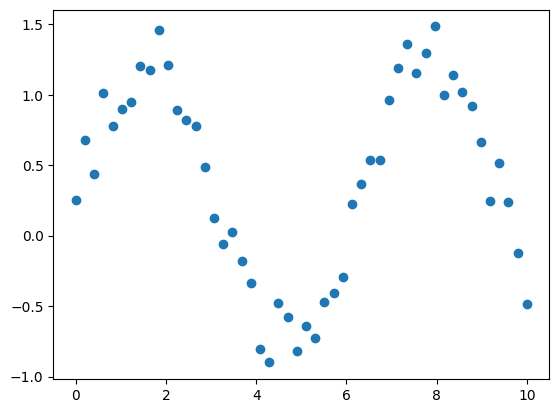

In [12]:
import matplotlib.pyplot as plt

data_x = np.linspace(0, 10, 50)
data_y = np.sin(data_x) + np.random.random(data_x.shape[0]) * 0.5
fig = plt.figure()
plt.plot(data_x, data_y, 'o')
plt.show()

### Podział na dane uczące i walidacyjne

Dane walidacyjne służą do monitorowania procesu uczenia, sprawdzania jak sieć radzi sobie z danymi, które nie są wykorzystywane do modyfikacji wag.

Jeśli błąd na danych uczących maleje, a na danych walidacyjnych już nie (lub wręcz rośnie), jest to potencjalny sygnał, że sieć jest przeczuczona.

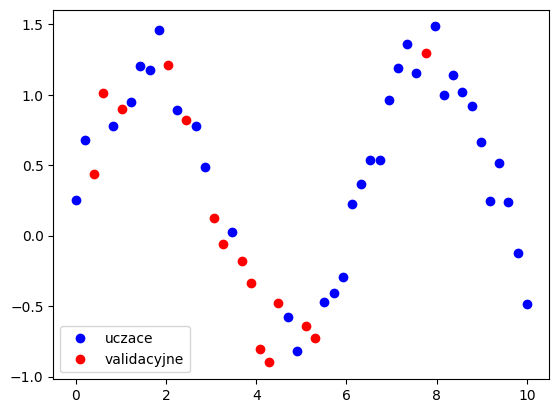

In [13]:
temp = np.arange(50)
np.random.shuffle(temp)
val_x = data_x[temp[35:]]
val_y = data_y[temp[35:]]
data_x = data_x[temp[:35]]
data_y = data_y[temp[:35]]

fig = plt.figure()
plt.plot(data_x, data_y, 'bo', label='uczace')
plt.plot(val_x, val_y, 'ro', label='validacyjne')
plt.legend()
plt.show()

### Model sieci MLP
Mała sieć, 35 neuronów w warstwie ukrytej.

In [14]:
x = Input(shape=(1,))
h = Dense(35, input_dim=1, use_bias=True, activation='tanh', kernel_initializer='random_uniform',
          bias_initializer='random_uniform')(x)
y = Dense(1, use_bias=True, activation='linear', kernel_initializer='random_uniform',
          bias_initializer='random_uniform')(h)
model1 = Model(inputs=x, outputs=y)
rms = tf.keras.optimizers.RMSprop(learning_rate=0.001)
model1.compile(loss='mse', optimizer=rms)
model1.summary()

/home/user/intro-to-ai/11/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 35)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106 (424.00 B)

 Trainable params: 106 (424.00 B)

 Non-trainable params: 0 (0.00 B)

### Wizualizacja uczenia

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step



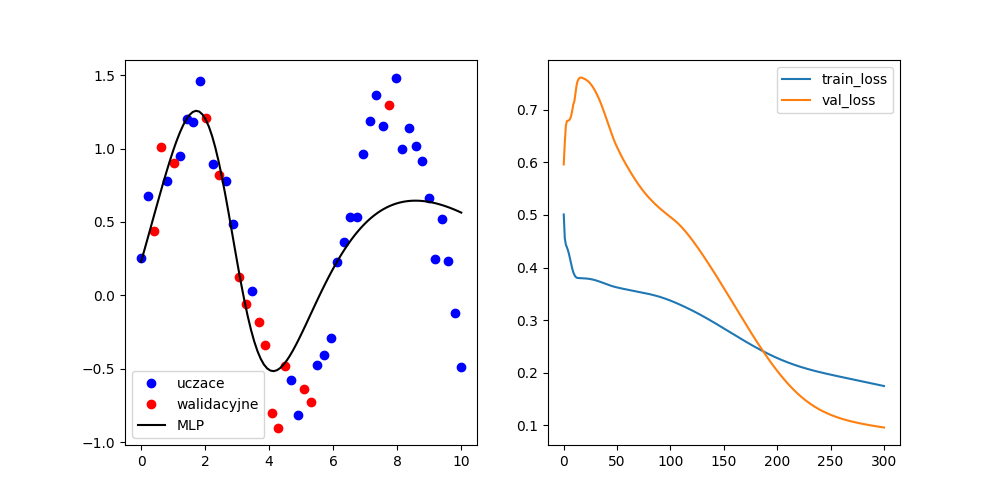

In [15]:
import io
import time
import base64
import IPython


def fig2b64(f):
	data = io.BytesIO()
	f.savefig(data, format='png')
	data.seek(0)
	return base64.b64encode(data.read()).decode()


data_xx = np.linspace(0, 10, 100)
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

train_loss = []
val_loss = []

model = model1
n_epochs = 300

hist = model.fit(data_x, data_y, epochs=10, verbose=0, batch_size=35, validation_data=(val_x, val_y))
train_loss.append(model.evaluate(data_x, data_y, verbose=0))
val_loss.append(model.evaluate(val_x, val_y, verbose=0))
pred = model.predict(data_xx)
ax1.plot(data_x, data_y, 'bo', label='uczace')
ax1.plot(val_x, val_y, 'ro', label='walidacyjne')
ax1.plot(data_xx, pred, 'k-', label='MLP')
ax1.legend()
ax2.plot(train_loss, label='train_loss')
ax2.plot(val_loss, label='val_loss')
ax2.legend()
data_str = fig2b64(fig)
rys = IPython.display.display_html(f'<img class="myimage" src="data:image/png;base64,{data_str}"></img>', raw=True)

for i in range(n_epochs):
	IPython.display.clear_output(wait=True)
	#time.sleep(0.2)
	hist = model.fit(data_x, data_y, epochs=10, verbose=0, batch_size=35, validation_data=(val_x, val_y))
	train_loss.append(model.evaluate(data_x, data_y, verbose=0))
	val_loss.append(model.evaluate(val_x, val_y, verbose=0))
	pred = model.predict(data_xx)
	ax1.clear()
	ax2.clear()
	ax1.plot(data_x, data_y, 'bo', label='uczace')
	ax1.plot(val_x, val_y, 'ro', label='walidacyjne')
	ax1.plot(data_xx, pred, 'k-', label='MLP')
	ax1.legend()
	ax2.plot(train_loss, label='train_loss')
	ax2.plot(val_loss, label='val_loss')
	ax2.legend()
	data_str = fig2b64(fig)
	rys = IPython.display.display_html(f'<img class="myimage" src="data:image/png;base64,{data_str}"></img>', raw=True)
plt.close(1)

### Model sieci MLP


Większa sieć, dwie warstwy ukryte odpowiednio 100 i 50 neuronów.

In [16]:
x = Input(shape=(1,))
h1 = Dense(100, input_dim=1, use_bias=True, activation='tanh', kernel_initializer='random_uniform',
           bias_initializer='random_uniform')(x)
h2 = Dense(50, input_dim=1, use_bias=True, activation='tanh', kernel_initializer='random_uniform',
           bias_initializer='random_uniform')(h1)
y = Dense(1, use_bias=True, activation='linear', kernel_initializer='random_uniform',
          bias_initializer='random_uniform')(h2)
model2 = Model(inputs=x, outputs=y)
rms = tf.keras.optimizers.RMSprop(learning_rate=0.001)
model2.compile(loss='mse', optimizer=rms)
model2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)

### Wizualizacja uczenia

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step



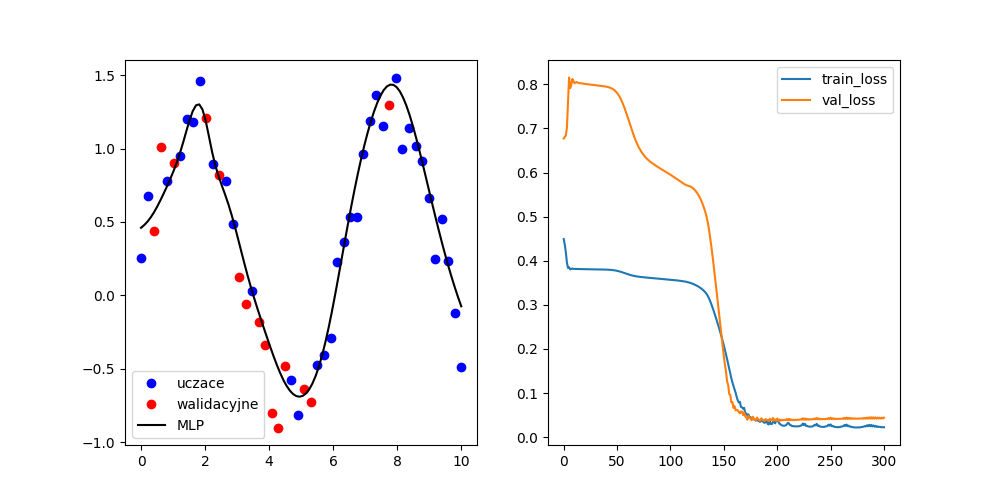

In [17]:
data_xx = np.linspace(0, 10, 100)
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

train_loss = []
val_loss = []

model = model2
n_epochs = 300

hist = model.fit(data_x, data_y, epochs=10, verbose=0, batch_size=35, validation_data=(val_x, val_y))
train_loss.append(model.evaluate(data_x, data_y, verbose=0))
val_loss.append(model.evaluate(val_x, val_y, verbose=0))
pred = model.predict(data_xx)
ax1.plot(data_x, data_y, 'bo', label='uczace')
ax1.plot(val_x, val_y, 'ro', label='walidacyjne')
ax1.plot(data_xx, pred, 'k-', label='MLP')
ax1.legend()
ax2.plot(train_loss, label='train_loss')
ax2.plot(val_loss, label='val_loss')
ax2.legend()
data_str = fig2b64(fig)
rys = IPython.display.display_html(f'<img class="myimage" src="data:image/png;base64,{data_str}"></img>', raw=True)

for i in range(n_epochs):
	IPython.display.clear_output(wait=True)
	#time.sleep(0.2)
	hist = model.fit(data_x, data_y, epochs=10, verbose=0, batch_size=35, validation_data=(val_x, val_y))
	train_loss.append(model.evaluate(data_x, data_y, verbose=0))
	val_loss.append(model.evaluate(val_x, val_y, verbose=0))
	pred = model.predict(data_xx)
	ax1.clear()
	ax2.clear()
	ax1.plot(data_x, data_y, 'bo', label='uczace')
	ax1.plot(val_x, val_y, 'ro', label='walidacyjne')
	ax1.plot(data_xx, pred, 'k-', label='MLP')
	ax1.legend()
	ax2.plot(train_loss, label='train_loss')
	ax2.plot(val_loss, label='val_loss')
	ax2.legend()
	data_str = fig2b64(fig)
	rys = IPython.display.display_html(f'<img class="myimage" src="data:image/png;base64,{data_str}"></img>', raw=True)
plt.close(1)

## Kiedy zakończyć uczenie?
Jednym z kluczowych aspektów (poza doborem architektury) jest zdecydowanie kiedy zakończyć uczenie sieci neuronowej. Najpopularniejsza technika polega na obserwacji wartości błedów osiąganych na zbiorze uczącym i zbiorze walidacyjnym. Gdy błąd na zbiorze walidacyjnym przestaje maleć (zazwyczaj zaczyna rosnąć) to znaczy, że sieć zaczyna się przeuczać (traci swoje zdalonośći generalizacyjne) i wtedy należy zakończyć proces uczenia. Taka strategia nazywa się strategią wczesnego zatrzymania (_early stopping_).

## Problemy klasyfikacyjne z wieloma klasami

Baza danych irysów zawiera przykłady z trzech klas. Zwróć uwagę na odpowiednie zakodowanie informacji o etykietach klas dla przykładów za pomocą funkcji `keras.utils.to_categorical`

In [18]:
from sklearn import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import SGD

iris_db = datasets.load_iris()
print(dir(iris_db))
print(type(iris_db.data))  #dane jako macierz numpy
print(iris_db.data.shape)  #kazdy przyklad w wierszu
print(iris_db.feature_names)  #nazwy atrybutow (sygnaly wejsciowe sieci)
print(iris_db.data[:10, :])  #podglad
print(iris_db.target_names)  #nazwy trzech klas
print(iris_db.target)  #etykiety klas zakodowane numerycznie jako 0, 1, 2

#d: zakodowane etykiety klas w sposob umozliwiajacy uczenie sieci
d = tf.keras.utils.to_categorical(iris_db.target, num_classes=3)
print(type(d))
print(d.shape)
print(d[:5, :])

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']
<class 'numpy.ndarray'>
(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
<class 'numpy.ndarray'>
(150, 3)
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


### Warstwa wyjściowa softmax

W warstwie wyjściowej softmax, każdy neuron realizuje sumę ważoną dochodzących do niego sygnałów wejściowych. Następnie, odpowiedzi wszystkich neuronów wyjściowych są przetwarzane zgodnie ze wzorem

$$P(y=j|\bf{x})=\frac{e^{\bf{x}^{T}\bf{w}_j}}{\sum_{k=1}^{K}{e^{\bf{x}^{T}\bf{w}_k}}}$$

gdzie $K$ to liczba neuronów wyjściowych (liczba klas w problemie klasyfikacyjnym), $w_j$ to wagi j-tego neuronu wyjściowego, $x$ to sygnały wejściowe neuronów z warstwy wyjściowej (odpowiedzi poprzedniej warstwy).

Wartości te mogą być interpretowane jako prawdopodobieństwa przynależności danego przykładu (podanego na wejście sieci) do danej klasy, którą reprezentuje j-ty neuron wyjściowy.

Dla takiej warstwy wyjściowej, funkcją straty używaną w trakcie uczenia jest zazwyczaj `categorical_entropy`, która mierzy podobieństwo dwóch rozkładów prawdopodobieństwa przynależności danych trenujących do klas: rzeczywisty (na podstawie zbioru trenującego) oraz ten realizowany przez sieć.

### Zapis i odczyt modelu do/z pliku

W poniższym przykładzie zwróć uwagę na zapis modelu do pliku i jego ponowne wczytanie.

In [19]:
model = Sequential()
model.add(Dense(30, activation='tanh', input_dim=4))
model.add(Dense(3, activation='softmax'))

sgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy',
              optimizer=sgd,
              metrics=['accuracy'])

model.fit(iris_db.data, d,
          epochs=200,
          batch_size=10)

score = model.evaluate(iris_db.data, d, batch_size=10)
print('model koncowy:', score)

#sprawdzenie czy dziala zapis/odczyt modelu z pliku
model.save('my_model.h5')
from tensorflow.keras.models import load_model

model2 = load_model('my_model.h5')
score2 = model2.evaluate(iris_db.data, d, batch_size=10)
print('model z pliku:', score2)

/home/user/intro-to-ai/11/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/user/intro-to-ai/11/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


ValueError: Argument(s) not recognized: {'lr': 0.01}

## Zadanie 1 (10 pkt., obowiązkowe)
Naucz sieć diagnozować cukrzycę.

- Wykorzytaj dane z pliku `pima-indians-diabetes.data.csv`. Dane są również dostępne w `sklearn`. Zaimportuje je jako `diab_db=datasets.load_diabetes()`

- Podziel dostępne dane losowo na dane uczące i testowe (walidacyjne) w proporcji 70% / 30%. Podział danych jest wykonywany raz i jest używany niezmieniony w dalszych obliczeniach dla wszystkich sieci.

- Dobierz jak najlepsze parametry uczenia oraz architektury sieci z jedną oraz z dwiema warstwami ukrytymi (po jednej na każdy rodzaj). Jakość działania sieci oceniamy na podstawie jej wyników na danych testowych. Postaraj się w odpowiednim momencie zatrzymać proces uczenia.

- Czy sieć z dwiema warstwami ukrytymi działa lepiej niż sieć z jedną warstwą ukrytą? Porównania i wnioski przedstaw na podstawie uśrednionych wyników dziesięciu sieci każdego rodzaju (tzn. najpierw ustal architekturę sieci, następnie przeprowadź 10 procesów trenownia, startując za każdym razem z losowych początkowych wag). 

- W dostarczonym kodzie umieść proces uczenia i testowania wybranych architektur sieci.

__Uwaga:__ Przy uczeniu większych modeli warto wykonywać obliczenia z wykorzystaniem karty graficznej. Aby uruchomić notatnik z wykorzystaniem GPU należy wejść do Edit->Notebook settings i zmienić Hardware accelerator na GPU.


TWÓJ KOD TUTAJ:

,family,hidden_layers,learning_rate,batch_size,val_acc,val_loss,epochs
0,1 warstwa,"(8,)",0.0010,16,0.7870,0.5002,45
1,1 warstwa,"(8,)",0.0003,16,0.7870,0.5002,103
2,1 warstwa,"(8,)",0.0010,32,0.7870,0.5015,57
3,1 warstwa,"(8,)",0.0003,32,0.7870,0.5021,143
4,1 warstwa,"(16,)",0.0003,16,0.7685,0.4882,160
5,1 warstwa,"(16,)",0.0010,16,0.7685,0.4887,58
6,1 warstwa,"(16,)",0.0003,32,0.7685,0.4908,233
7,1 warstwa,"(16,)",0.0010,32,0.7685,0.4913,81
8,1 warstwa,"(64,)",0.0010,16,0.7685,0.5087,33
9,1 warstwa,"(64,)",0.0003,16,0.7593,0.5087,60


,hidden_layers,learning_rate,batch_size,val_acc,val_loss,epochs
1 warstwa ukryta,"(8,)",0.0010,16,0.7870,0.5002,45
2 warstwy ukryte,"(32, 16)",0.0010,32,0.7778,0.5047,87


,label,run,test_acc,test_loss,val_acc,val_loss,epochs
0,1 warstwa ukryta,3,0.7576,0.4562,0.7315,0.5143,53
1,1 warstwa ukryta,8,0.7532,0.4889,0.7407,0.5095,39
2,1 warstwa ukryta,6,0.7489,0.5256,0.7593,0.4823,217
3,1 warstwa ukryta,4,0.7446,0.5163,0.7407,0.5019,129
4,1 warstwa ukryta,10,0.7446,0.4780,0.7407,0.4914,56
5,1 warstwa ukryta,1,0.7359,0.4921,0.7870,0.5002,45
6,1 warstwa ukryta,5,0.7316,0.4744,0.7593,0.5002,135
7,1 warstwa ukryta,2,0.7273,0.5152,0.7037,0.5445,88
8,1 warstwa ukryta,9,0.7273,0.4918,0.7870,0.4771,78
9,1 warstwa ukryta,7,0.7186,0.4888,0.7593,0.5111,53


,label,mean_test_acc,std_test_acc,mean_test_loss,std_test_loss,mean_epochs,best_test_acc,best_run
0,1 warstwa ukryta,0.7390,0.0128,0.4927,0.0212,89.3,0.7576,3
1,2 warstwy ukryte,0.7407,0.0131,0.4954,0.0351,56.2,0.7662,1


Model 1 warstwa ukryta
[[129  21]
 [ 35  46]]
              precision    recall  f1-score   support

         0.0     0.7866    0.8600    0.8217       150
         1.0     0.6866    0.5679    0.6216        81

    accuracy                         0.7576       231
   macro avg     0.7366    0.7140    0.7216       231
weighted avg     0.7515    0.7576    0.7515       231

Model 2 warstwy ukryte
[[129  21]
 [ 33  48]]
              precision    recall  f1-score   support

         0.0     0.7963    0.8600    0.8269       150
         1.0     0.6957    0.5926    0.6400        81

    accuracy                         0.7662       231
   macro avg     0.7460    0.7263    0.7335       231
weighted avg     0.7610    0.7662    0.7614       231



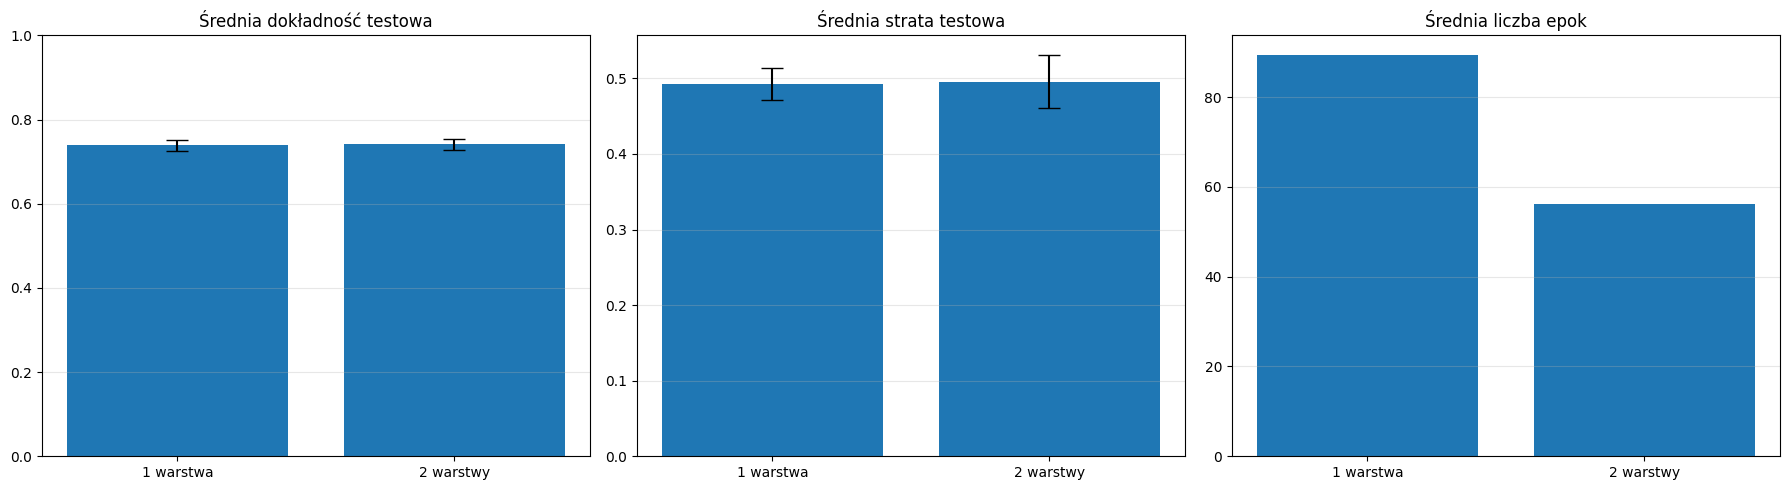

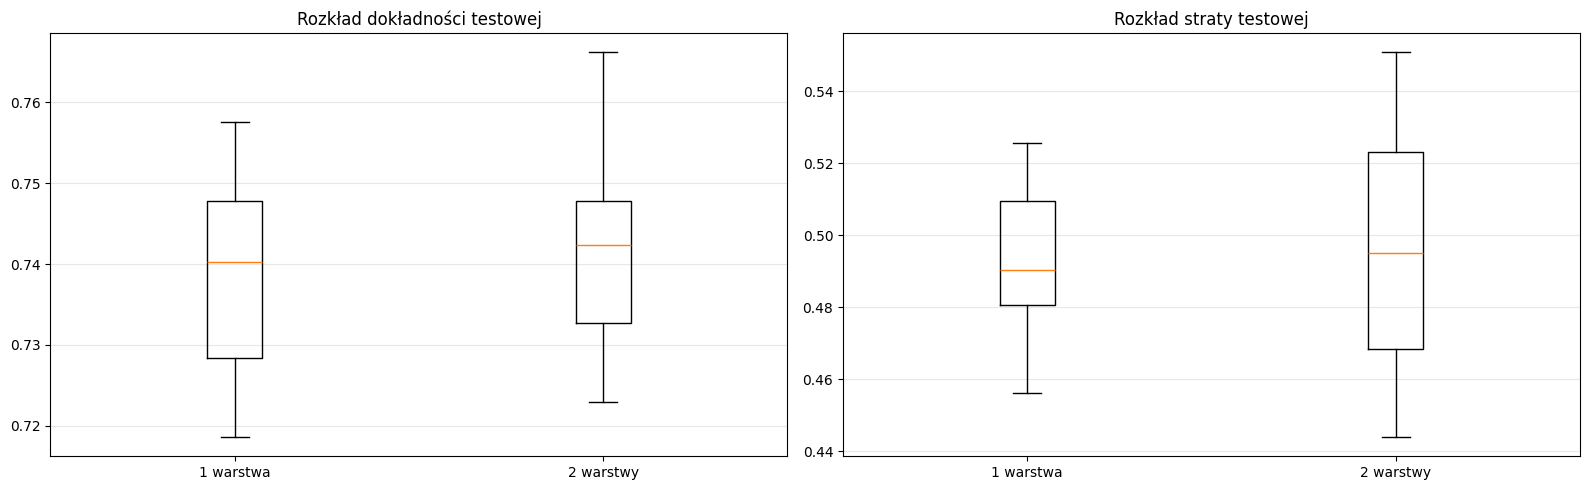

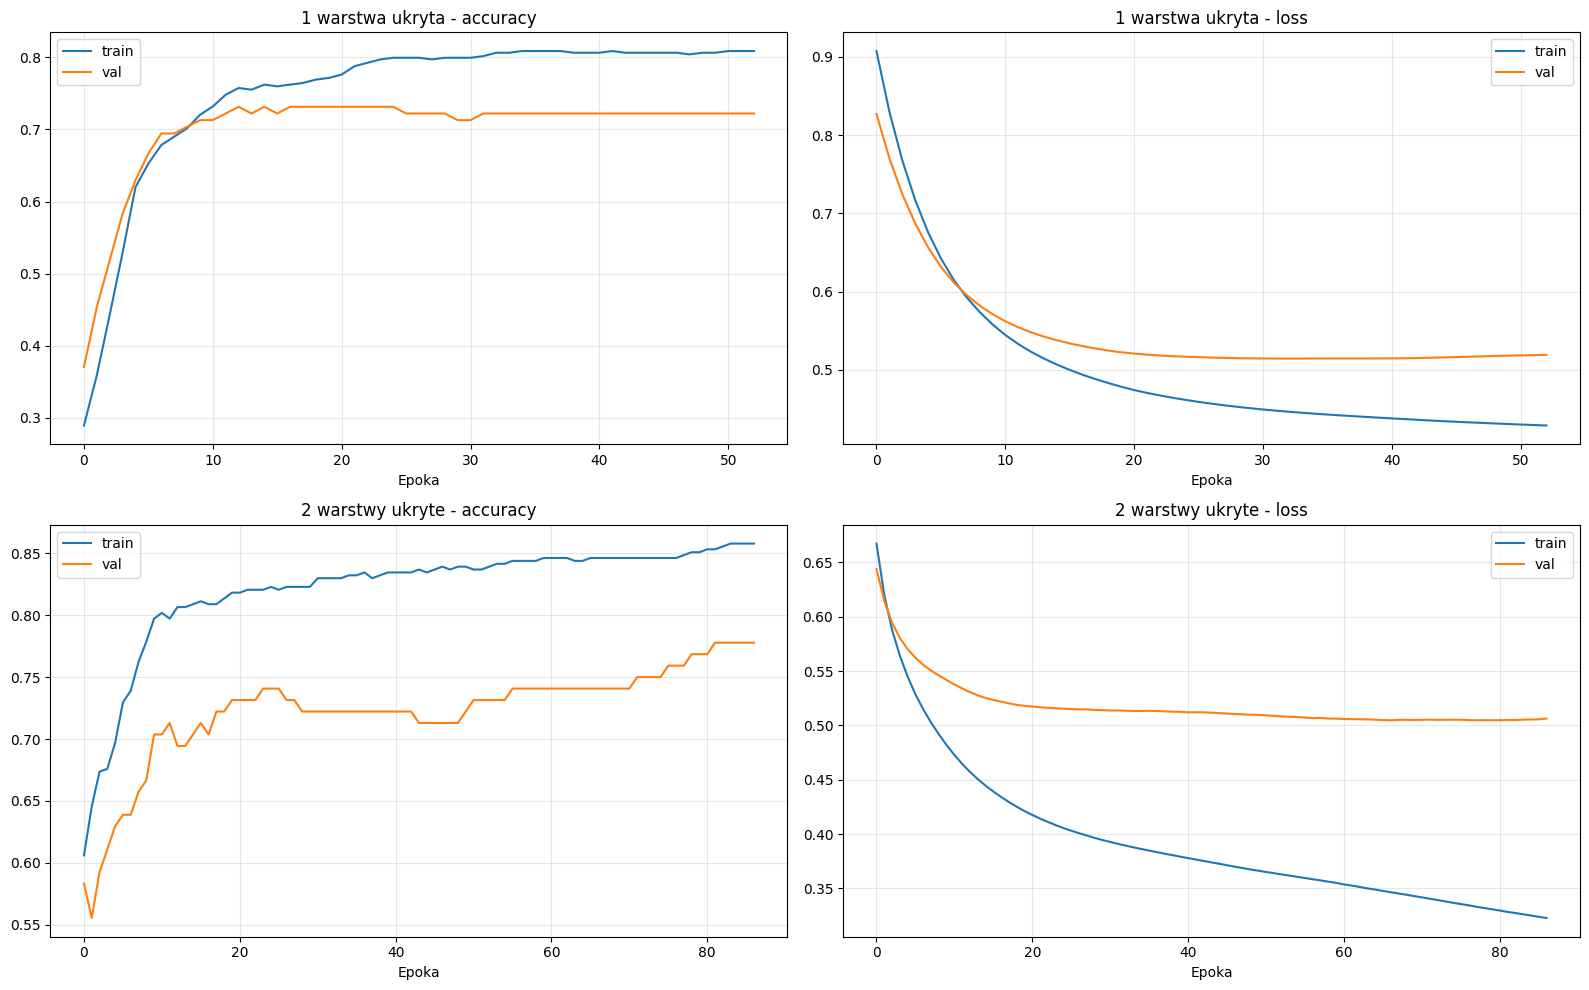

Najlepsza architektura 1 warstwa: {'hidden_layers': (8,), 'learning_rate': 0.001, 'batch_size': 16, 'val_acc': 0.7870370149612427, 'val_loss': 0.5001522302627563, 'epochs': 45}
Najlepsza architektura 2 warstwy: {'hidden_layers': (32, 16), 'learning_rate': 0.001, 'batch_size': 32, 'val_acc': 0.7777777910232544, 'val_loss': 0.5047349333763123, 'epochs': 87}
Wyniki 1 warstwa: {'label': '1 warstwa ukryta', 'mean_test_acc': 0.7389610389610389, 'std_test_acc': 0.01275241044460935, 'mean_test_loss': 0.49271622598171233, 'std_test_loss': 0.021239502278185093, 'mean_epochs': 89.3, 'best_test_acc': 0.7575757575757576, 'best_run': 3}
Wyniki 2 warstwy: {'label': '2 warstwy ukryte', 'mean_test_acc': 0.7406926406926406, 'std_test_acc': 0.013138446914966873, 'mean_test_loss': 0.49535769820213316, 'std_test_loss': 0.035076747719599205, 'mean_epochs': 56.2, 'best_test_acc': 0.7662337662337663, 'best_run': 1}
Wniosek:  model z 2 warstwami ukrytymi nie daje tu wyraźnej przewagi nad modelem z 1 warstwą uk

In [23]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

seed_base = 42
np.random.seed(seed_base)
random.seed(seed_base)
tf.keras.utils.set_random_seed(seed_base)

candidates = [
	Path.cwd() / "pima-indians-diabetes.data.csv",
	Path("/mnt/data") / "pima-indians-diabetes.data.csv",
]
data_path = next((p for p in candidates if p.exists()), None)

if data_path is None:
	matches = list(Path.cwd().rglob("pima-indians-diabetes.data.csv"))

	if not matches:
		matches = list(Path("/mnt/data").rglob("pima-indians-diabetes.data.csv"))

	if not matches:
		raise FileNotFoundError("Nie znaleziono pliku pima-indians-diabetes.data.csv")

	data_path = matches[0]

data = np.loadtxt(data_path, delimiter=",")
X = data[:, :-1].astype(np.float32)
y = data[:, -1].astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.3, random_state=seed_base, stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

for col in [1, 2, 3, 4, 5]:
	X_train[X_train[:, col] == 0, col] = np.nan
	X_test[X_test[:, col] == 0, col] = np.nan

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

feature_names = [
	"Pregnancies",
	"Glucose",
	"BloodPressure",
	"SkinThickness",
	"Insulin",
	"BMI",
	"DiabetesPedigreeFunction",
	"Age",
]


def build_model(hidden_layers, learning_rate):
	model = Sequential()
	model.add(Input(shape=(X_train.shape[1],)))

	for units in hidden_layers:
		model.add(Dense(units, activation="relu"))

	model.add(Dense(1, activation="sigmoid"))
	model.compile(
		optimizer=Adam(learning_rate=learning_rate),
		loss="binary_crossentropy",
		metrics=["accuracy"],
	)

	return model


def tune_architecture(architectures, learning_rates, batch_sizes, name):
	rows = []
	best = None

	for hidden_layers in architectures:
		for lr in learning_rates:
			for batch_size in batch_sizes:
				tf.keras.backend.clear_session()
				tf.keras.utils.set_random_seed(seed_base)

				model = build_model(hidden_layers, lr)

				es = EarlyStopping(
					monitor="val_loss",
					patience=20,
					restore_best_weights=True,
					verbose=0,
				)

				history = model.fit(
					X_train,
					y_train,
					validation_split=0.2,
					epochs=300,
					batch_size=batch_size,
					verbose=0,
					callbacks=[es],
					shuffle=True,
				)

				val_acc = float(np.max(history.history["val_accuracy"]))
				val_loss = float(np.min(history.history["val_loss"]))

				row = {
					"family": name,
					"hidden_layers": str(hidden_layers),
					"learning_rate": lr,
					"batch_size": batch_size,
					"val_acc": val_acc,
					"val_loss": val_loss,
					"epochs": len(history.history["loss"]),
				}

				rows.append(row)

				if best is None or val_acc > best["val_acc"] or (
						val_acc == best["val_acc"] and val_loss < best["val_loss"]
				):
					best = {
						"hidden_layers": hidden_layers,
						"learning_rate": lr,
						"batch_size": batch_size,
						"val_acc": val_acc,
						"val_loss": val_loss,
						"epochs": len(history.history["loss"]),
					}

	return pd.DataFrame(rows), best


def train_10(hidden_layers, learning_rate, batch_size, label):
	rows = []
	histories = []
	predictions = []

	for i in range(10):
		tf.keras.backend.clear_session()
		tf.keras.utils.set_random_seed(seed_base + i)

		model = build_model(hidden_layers, learning_rate)

		es = EarlyStopping(
			monitor="val_loss",
			patience=20,
			restore_best_weights=True,
			verbose=0,
		)

		history = model.fit(
			X_train,
			y_train,
			validation_split=0.2,
			epochs=300,
			batch_size=batch_size,
			verbose=0,
			callbacks=[es],
			shuffle=True,
		)

		prob = model(X_test, training=False).numpy().ravel()
		pred = (prob >= 0.5).astype(int)

		acc = accuracy_score(y_test, pred)
		test_loss = float(model.evaluate(X_test, y_test, verbose=0)[0])

		val_acc = float(np.max(history.history["val_accuracy"]))
		val_loss = float(np.min(history.history["val_loss"]))

		rows.append(
			{
				"label": label,
				"run": i + 1,
				"test_acc": acc,
				"test_loss": test_loss,
				"val_acc": val_acc,
				"val_loss": val_loss,
				"epochs": len(history.history["loss"]),
			}
		)

		histories.append(history)
		predictions.append((prob, pred))

	df = pd.DataFrame(rows)

	summary = pd.DataFrame(
		[
			{
				"label": label,
				"mean_test_acc": df["test_acc"].mean(),
				"std_test_acc": df["test_acc"].std(ddof=1),
				"mean_test_loss": df["test_loss"].mean(),
				"std_test_loss": df["test_loss"].std(ddof=1),
				"mean_epochs": df["epochs"].mean(),
				"best_test_acc": df["test_acc"].max(),
				"best_run": int(df.loc[df["test_acc"].idxmax(), "run"]),
			}
		]
	)
	return df, summary, histories, predictions


one_layer_candidates = [(8,), (16,), (32,), (64,)]
two_layer_candidates = [(16, 8), (32, 16), (64, 32)]
learning_rates = [0.001, 0.0003]
batch_sizes = [16, 32]

search_one_df, best_one = tune_architecture(one_layer_candidates, learning_rates, batch_sizes, "1 warstwa")
search_two_df, best_two = tune_architecture(two_layer_candidates, learning_rates, batch_sizes, "2 warstwy")

display(
	pd.concat([search_one_df, search_two_df], ignore_index=True)
	.sort_values(["family", "val_acc", "val_loss"], ascending=[True, False, True])
	.reset_index(drop=True)
	.style.format(
		{
			"learning_rate": "{:.4f}",
			"val_acc": "{:.4f}",
			"val_loss": "{:.4f}",
			"epochs": "{:.0f}",
		}
	)
)

display(
	pd.DataFrame([best_one, best_two], index=["1 warstwa ukryta", "2 warstwy ukryte"]).style.format(
		{
			"learning_rate": "{:.4f}",
			"val_acc": "{:.4f}",
			"val_loss": "{:.4f}",
			"epochs": "{:.0f}",
		}
	)
)

df_one_runs, summary_one, histories_one, preds_one = train_10(
	best_one["hidden_layers"], best_one["learning_rate"], best_one["batch_size"], "1 warstwa ukryta"
)
df_two_runs, summary_two, histories_two, preds_two = train_10(
	best_two["hidden_layers"], best_two["learning_rate"], best_two["batch_size"], "2 warstwy ukryte"
)

display(
	pd.concat([df_one_runs, df_two_runs], ignore_index=True)
	.sort_values(["label", "test_acc"], ascending=[True, False])
	.reset_index(drop=True)
	.style.format(
		{
			"test_acc": "{:.4f}",
			"test_loss": "{:.4f}",
			"val_acc": "{:.4f}",
			"val_loss": "{:.4f}",
			"epochs": "{:.0f}",
		}
	)
)

display(
	pd.concat([summary_one, summary_two], ignore_index=True).style.format(
		{
			"mean_test_acc": "{:.4f}",
			"std_test_acc": "{:.4f}",
			"mean_test_loss": "{:.4f}",
			"std_test_loss": "{:.4f}",
			"mean_epochs": "{:.1f}",
			"best_test_acc": "{:.4f}",
		}
	)
)

best_idx_one = df_one_runs["test_acc"].idxmax()
best_idx_two = df_two_runs["test_acc"].idxmax()

prob_one, pred_one = preds_one[best_idx_one]
prob_two, pred_two = preds_two[best_idx_two]

print("Model 1 warstwa ukryta")
print(confusion_matrix(y_test, pred_one))
print(classification_report(y_test, pred_one, digits=4))

print("Model 2 warstwy ukryte")
print(confusion_matrix(y_test, pred_two))
print(classification_report(y_test, pred_two, digits=4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["1 warstwa", "2 warstwy"]
means_acc = [summary_one["mean_test_acc"].iloc[0], summary_two["mean_test_acc"].iloc[0]]
std_acc = [summary_one["std_test_acc"].iloc[0], summary_two["std_test_acc"].iloc[0]]
means_loss = [summary_one["mean_test_loss"].iloc[0], summary_two["mean_test_loss"].iloc[0]]
std_loss = [summary_one["std_test_loss"].iloc[0], summary_two["std_test_loss"].iloc[0]]
means_epochs = [summary_one["mean_epochs"].iloc[0], summary_two["mean_epochs"].iloc[0]]

axes[0].bar(labels, means_acc, yerr=std_acc, capsize=8)
axes[0].set_title("Średnia dokładność testowa")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(labels, means_loss, yerr=std_loss, capsize=8)
axes[1].set_title("Średnia strata testowa")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(labels, means_epochs)
axes[2].set_title("Średnia liczba epok")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].boxplot([df_one_runs["test_acc"], df_two_runs["test_acc"]], tick_labels=labels)
axes[0].set_title("Rozkład dokładności testowej")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot([df_one_runs["test_loss"], df_two_runs["test_loss"]], tick_labels=labels)
axes[1].set_title("Rozkład straty testowej")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

best_hist_one = histories_one[best_idx_one]
best_hist_two = histories_two[best_idx_two]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(best_hist_one.history["accuracy"], label="train")
axes[0, 0].plot(best_hist_one.history["val_accuracy"], label="val")
axes[0, 0].set_title("1 warstwa ukryta - accuracy")
axes[0, 0].set_xlabel("Epoka")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(best_hist_one.history["loss"], label="train")
axes[0, 1].plot(best_hist_one.history["val_loss"], label="val")
axes[0, 1].set_title("1 warstwa ukryta - loss")
axes[0, 1].set_xlabel("Epoka")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(best_hist_two.history["accuracy"], label="train")
axes[1, 0].plot(best_hist_two.history["val_accuracy"], label="val")
axes[1, 0].set_title("2 warstwy ukryte - accuracy")
axes[1, 0].set_xlabel("Epoka")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(best_hist_two.history["loss"], label="train")
axes[1, 1].plot(best_hist_two.history["val_loss"], label="val")
axes[1, 1].set_title("2 warstwy ukryte - loss")
axes[1, 1].set_xlabel("Epoka")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Najlepsza architektura 1 warstwa:", best_one)
print("Najlepsza architektura 2 warstwy:", best_two)
print("Wyniki 1 warstwa:", summary_one.to_dict(orient="records")[0])
print("Wyniki 2 warstwy:", summary_two.to_dict(orient="records")[0])
print("Wniosek: ", "model z 2 warstwami ukrytymi nie daje tu wyraźnej przewagi nad modelem z 1 warstwą ukrytą, bo średnia accuracy jest bardzo zbliżona.")

TWOJE KOMENTARZE I WNIOSKI

Z tych wyników nie widać wyraźnej przewagi sieci z dwiema warstwami ukrytymi. Jedna warstwa dała minimalnie lepszy wynik na walidacji, a średnia dokładność na teście wyszła praktycznie taka sama w obu przypadkach.

&copy; Cracow University of Technology